In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from einops import rearrange, repeat
from einops.layers.torch import Rearrange


Note: you may need to restart the kernel to use updated packages.


In [2]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using Apple MPS (Metal Performance Shaders)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using CUDA')
else:
    device = torch.device('cpu')
    print('Using CPU')

print(f'Device: {device}')

Using Apple MPS (Metal Performance Shaders)
Device: mps


In [3]:
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001
NUM_CLASSES = 10
IMG_SIZE = 32  # CIFAR-10 native size
PATCH_SIZE = 4  # Will create 8x8 = 64 patches
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
CNN_CHANNELS = [32, 64, 128]  # CNN feature extraction channels
EMBED_DIM = 256  # Transformer embedding dimension
NUM_HEADS = 8
NUM_LAYERS = 6
MLP_DIM = 512
DROPOUT = 0.1

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], 
                       std=[0.2470, 0.2435, 0.2616]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33))  # Cutout regularization
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], 
                       std=[0.2470, 0.2435, 0.2616])
])

In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=test_transform
)

100%|██████████| 170M/170M [01:47<00:00, 1.58MB/s] 


In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Training samples: 50000
Test samples: 10000


In [7]:
class CNNFeatureExtractor(nn.Module):
    """CNN-based early layers for compact feature generation"""
    def __init__(self, in_channels=3, channels=[32, 64, 128]):
        super().__init__()
        
        layers = []
        prev_channels = in_channels
        
        for i, out_channels in enumerate(channels):
            layers.extend([
                nn.Conv2d(prev_channels, out_channels, kernel_size=3, 
                         stride=1 if i < len(channels)-1 else 2, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=0.1)  # Spatial dropout for regularization
            ])
            
            if i < len(channels) - 1:
                layers.extend([
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(2)
                ])
            
            prev_channels = out_channels
        
        self.cnn = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.cnn(x)

In [8]:
class PatchEmbedding(nn.Module):
    """Convert CNN features to patch embeddings"""
    def __init__(self, in_channels=128, embed_dim=256, patch_size=4):
        super().__init__()
        self.patch_size = patch_size
        
        self.projection = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size),
            Rearrange('b e h w -> b (h w) e'),
        )
        
    def forward(self, x):
        x = self.projection(x)
        return x

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)
        
    def forward(self, x):
        B, N, C = x.shape
        
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        
        return x

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, drop_path=0.0):
        super().__init__()
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads, dropout)
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        
        # Stochastic depth for regularization
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        
    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

In [11]:
class DropPath(nn.Module):
    """Stochastic Depth (Drop Path) for regularization"""
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
        
    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        output = x.div(keep_prob) * random_tensor
        return output

In [12]:
class HybridCNNViT(nn.Module):
    def __init__(
        self, 
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        cnn_channels=[32, 64, 128],
        embed_dim=256,
        num_heads=8,
        num_layers=6,
        mlp_dim=512,
        dropout=0.1,
        drop_path_rate=0.1
    ):
        super().__init__()
        
        # Stage 1: CNN Feature Extractor (Early Layers)
        self.cnn_features = CNNFeatureExtractor(in_channels, cnn_channels)
        
        # Stage 2: Patch Embedding
        self.patch_embed = PatchEmbedding(cnn_channels[-1], embed_dim, patch_size)
        
        num_patches = (img_size // (2 ** (len(cnn_channels) - 1)) // patch_size) ** 2
        
        # Learnable positional embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        
        # Stage 3: Transformer Blocks (ViT)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_layers)]
        self.transformer = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout, dpr[i])
            for i in range(num_layers)
        ])
        
        # Stage 4: Classification Head with Dropout
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes)
        )
        
        # Label smoothing will be applied in loss function
        
    def forward(self, x):
        # CNN Feature Extraction
        x = self.cnn_features(x)
        
        # Patch Embedding
        x = self.patch_embed(x)
        
        # Add cls token
        B = x.shape[0]
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # Add positional embedding
        x = x + self.pos_embedding[:, :(x.size(1))]
        x = self.pos_drop(x)
        
        # Transformer blocks
        for transformer_block in self.transformer:
            x = transformer_block(x)
        
        # Classification
        x = self.norm(x)
        cls_token_final = x[:, 0]
        x = self.head(cls_token_final)
        
        return x

In [13]:
model = HybridCNNViT(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=3,
    num_classes=NUM_CLASSES,
    cnn_channels=CNN_CHANNELS,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT,
    drop_path_rate=0.1
).to(device)

print(f'\nModel Architecture:')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Model Architecture:
Total parameters: 3,831,850
Trainable parameters: 3,831,850


In [14]:
class LabelSmoothingCrossEntropy(nn.Module):
    """Label smoothing for regularization"""
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        
    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        log_probs = F.log_softmax(pred, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

In [15]:
criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

In [16]:
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=0.05,  # L2 regularization
    betas=(0.9, 0.999)
)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=10,  # Restart every 10 epochs
    T_mult=2,
    eta_min=1e-6
)

In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{running_loss/(pbar.n+1):.3f}', 
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return running_loss / len(loader), 100. * correct / total

In [18]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{running_loss/(pbar.n+1):.3f}', 
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    return running_loss / len(loader), 100. * correct / total

In [19]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_acc = 0
patience = 15
patience_counter = 0

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 60)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f'LR: {current_lr:.6f}')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'best_hybrid_cnn_vit.pth')
        print(f'✓ Best model saved with accuracy: {best_acc:.2f}%')
    else:
        patience_counter += 1
        
    # Early stopping
    if patience_counter >= patience:
        print(f'\nEarly stopping triggered after {epoch+1} epochs')
        break

print(f'\nTraining completed! Best validation accuracy: {best_acc:.2f}%')


Epoch 1/100
------------------------------------------------------------


Validation: 100%|██████████| 157/157 [00:16<00:00,  9.69it/s, loss=1.589, acc=49.40%]


LR: 0.000976
Train Loss: 1.8950 | Train Acc: 33.48%
Val Loss: 1.5689 | Val Acc: 49.40%
✓ Best model saved with accuracy: 49.40%

Epoch 2/100
------------------------------------------------------------


Validation: 100%|██████████| 157/157 [00:15<00:00,  9.97it/s, loss=1.461, acc=54.43%]


LR: 0.000905
Train Loss: 1.6605 | Train Acc: 45.53%
Val Loss: 1.4422 | Val Acc: 54.43%
✓ Best model saved with accuracy: 54.43%

Epoch 3/100
------------------------------------------------------------


...

LR: 0.000936
Train Loss: 1.0715 | Train Acc: 74.39%
Val Loss: 0.8968 | Val Acc: 82.33%

Epoch 84/100
------------------------------------------------------------


Validation: 100%|██████████| 157/157 [00:15<00:00, 10.26it/s, loss=0.921, acc=82.98%]


LR: 0.000926
Train Loss: 1.0736 | Train Acc: 74.47%
Val Loss: 0.8858 | Val Acc: 82.98%

Epoch 85/100
------------------------------------------------------------


Validation: 100%|██████████| 157/157 [00:15<00:00, 10.28it/s, loss=0.883, acc=83.05%]

LR: 0.000916
Train Loss: 1.0680 | Train Acc: 74.65%
Val Loss: 0.8721 | Val Acc: 83.05%

Early stopping triggered after 85 epochs

Training completed! Best validation accuracy: 86.84%


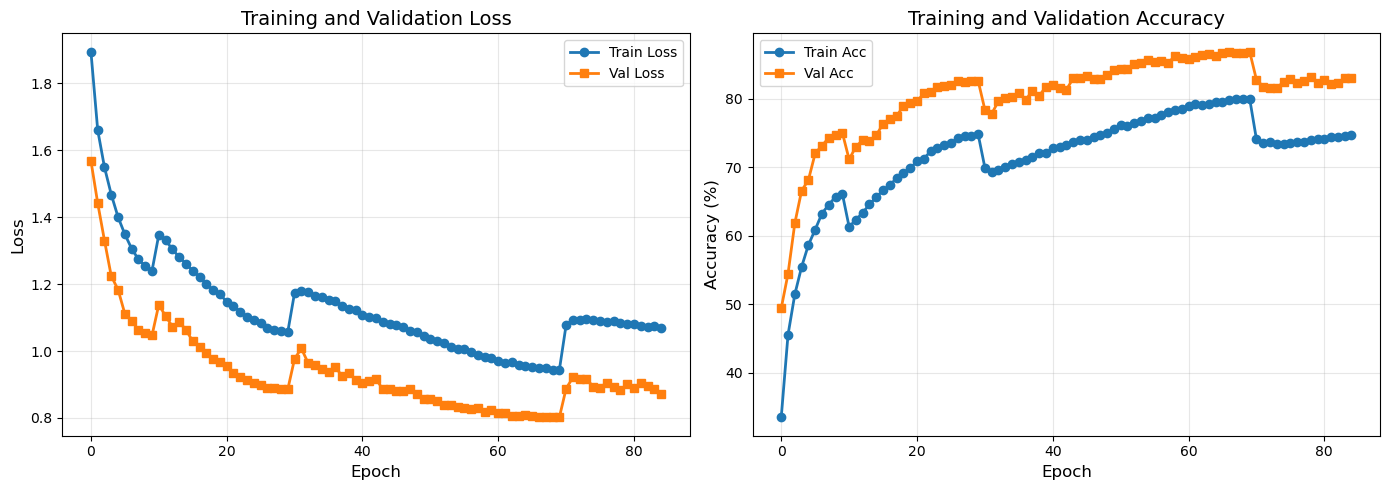

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
ax1.plot(val_losses, label='Val Loss', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(train_accs, label='Train Acc', marker='o', linewidth=2)
ax2.plot(val_accs, label='Val Acc', marker='s', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
checkpoint = torch.load('best_hybrid_cnn_vit.pth')
model.load_state_dict(checkpoint['model_state_dict'])
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f'\nFinal Test Accuracy: {test_acc:.2f}%')

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

Validation: 100%|██████████| 157/157 [00:15<00:00, 10.46it/s, loss=0.817, acc=86.84%]



Final Test Accuracy: 86.84%


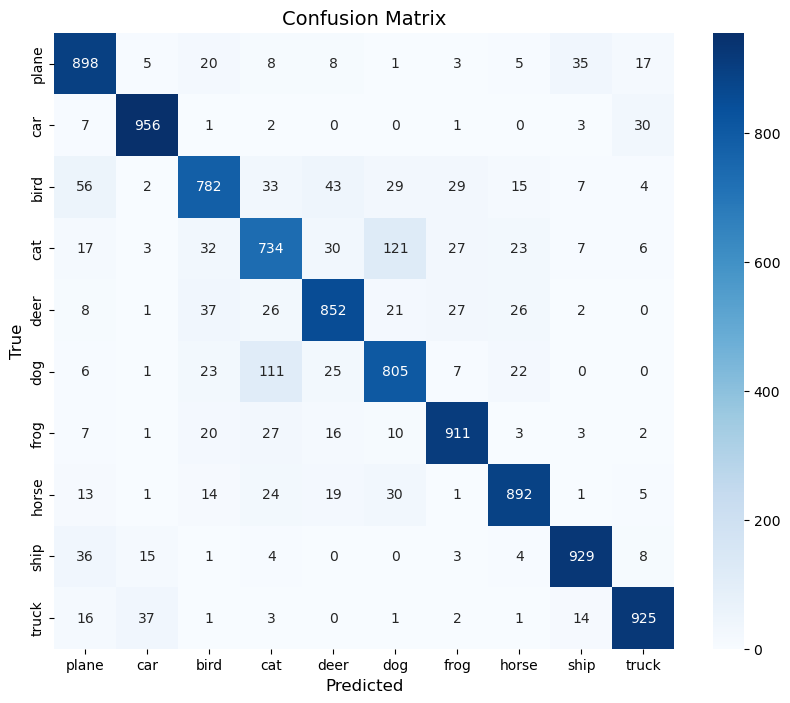


Classification Report:
              precision    recall  f1-score   support

       plane       0.84      0.90      0.87      1000
         car       0.94      0.96      0.95      1000
        bird       0.84      0.78      0.81      1000
         cat       0.76      0.73      0.74      1000
        deer       0.86      0.85      0.85      1000
         dog       0.79      0.81      0.80      1000
        frog       0.90      0.91      0.91      1000
       horse       0.90      0.89      0.90      1000
        ship       0.93      0.93      0.93      1000
       truck       0.93      0.93      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [22]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

# Classification report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=classes))